In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
X,y = make_circles(n_samples=1000,noise=0.1,factor=0.5,random_state=42)

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [7]:
def build_model():
    model = Sequential([
        Dense(16,input_shape=(2,),activation='relu'),
        Dense(8,activation='relu'),
        Dense(1,activation='sigmoid')])
    return model

In [8]:
model_momentum = build_model()
model_momentum.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),loss='binary_crossentropy',metrics=['accuracy'])

model_nag = build_model()
model_nag.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9,nesterov=True),loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
epochs = 50
batch_size=32
print("training model with momentum")
history_momentum = model_momentum.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=epochs,batch_size=batch_size,verbose=0)

print("training model with nag")
history_nag = model_nag.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=epochs,batch_size=batch_size,verbose=0)

training model with momentum
training model with nag


In [11]:
loss_mom,acc_mom = model_momentum.evaluate(X_test,y_test,verbose=0)
loss_nag,acc_nag = model_nag.evaluate(X_test,y_test,verbose=0)
print(f"\nfinal momentum test accuracy : {acc_mom*100:.2f}%")
print(f"\nfinal nag test accuracy : {acc_nag*100:.2f}%")


final momentum test accuracy : 97.00%

final nag test accuracy : 97.50%


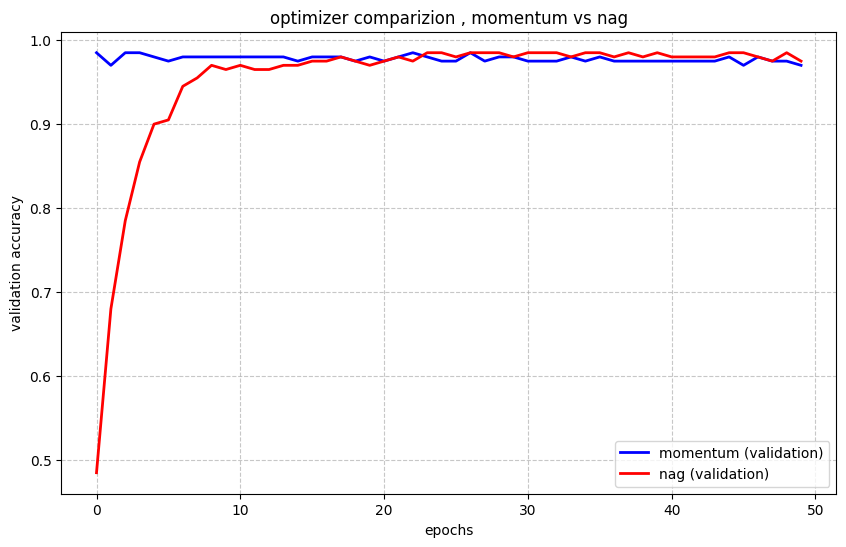

In [14]:
plt.figure(figsize=(10,6))
plt.plot(history_momentum.history['val_accuracy'],label='momentum (validation)',color='blue',linewidth=2)
plt.plot(history_nag.history['val_accuracy'],label='nag (validation)',color='red',linewidth=2)
plt.title('optimizer comparizion , momentum vs nag')
plt.xlabel('epochs')
plt.ylabel('validation accuracy')
plt.legend(loc='lower right')
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()